Dataset Shape: (11162, 17)

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']

First 5 Rows:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   m

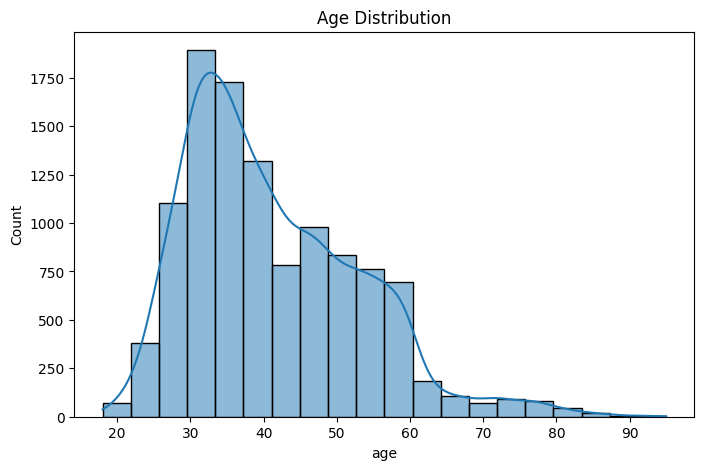

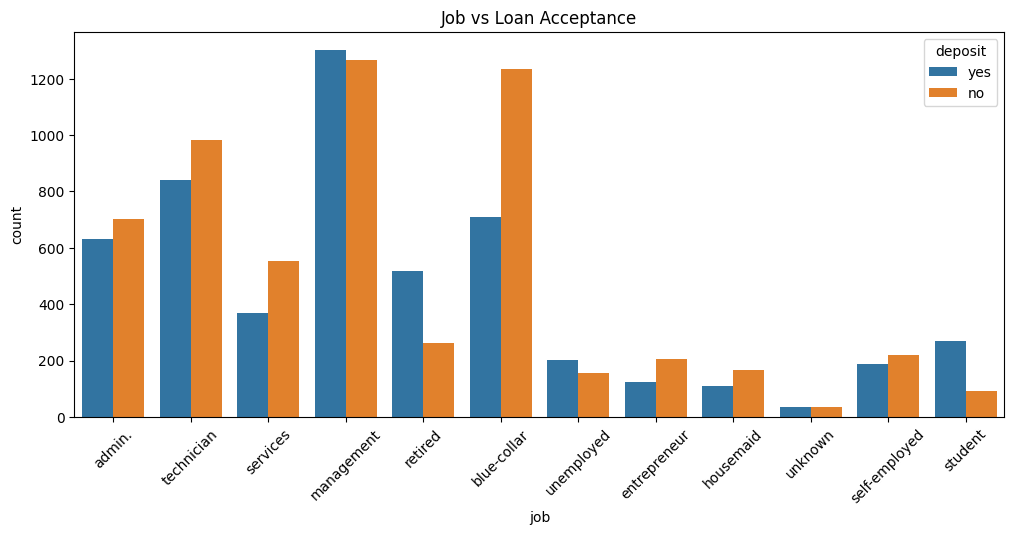

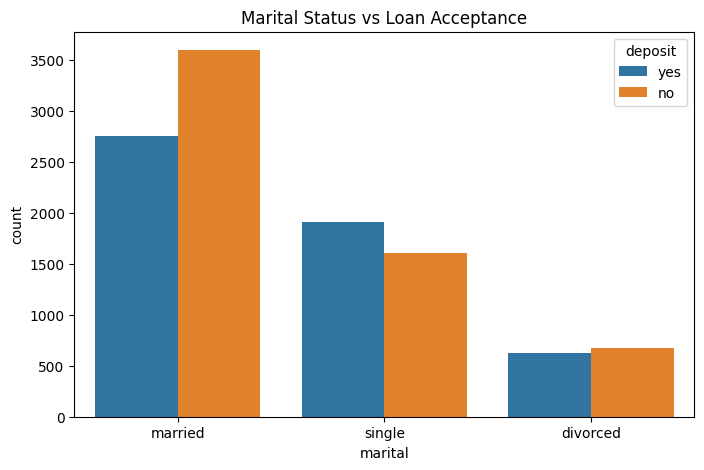

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Accuracy: 0.7823555754590238

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.80      0.79      1166
           1       0.78      0.76      0.77      1067

    accuracy                           0.78      2233
   macro avg       0.78      0.78      0.78      2233
weighted avg       0.78      0.78      0.78      2233



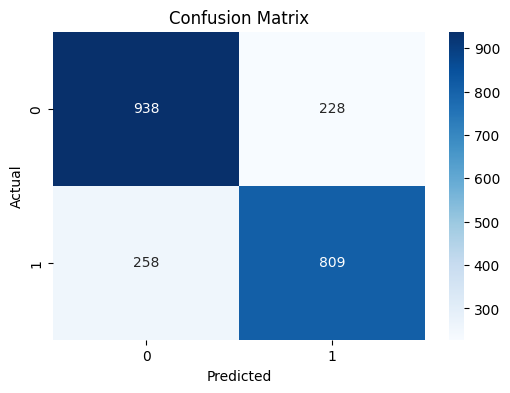


Top Features:
      Feature  Coefficient       Abs
6     housing    -0.882959  0.882959
8     contact    -0.753127  0.753127
7        loan    -0.333573  0.333573
3   education     0.177895  0.177895
15   poutcome    -0.159668  0.159668
12   campaign    -0.156579  0.156579
14   previous     0.069121  0.069121
2     marital    -0.052866  0.052866
4     default    -0.036085  0.036085
10      month     0.027781  0.027781


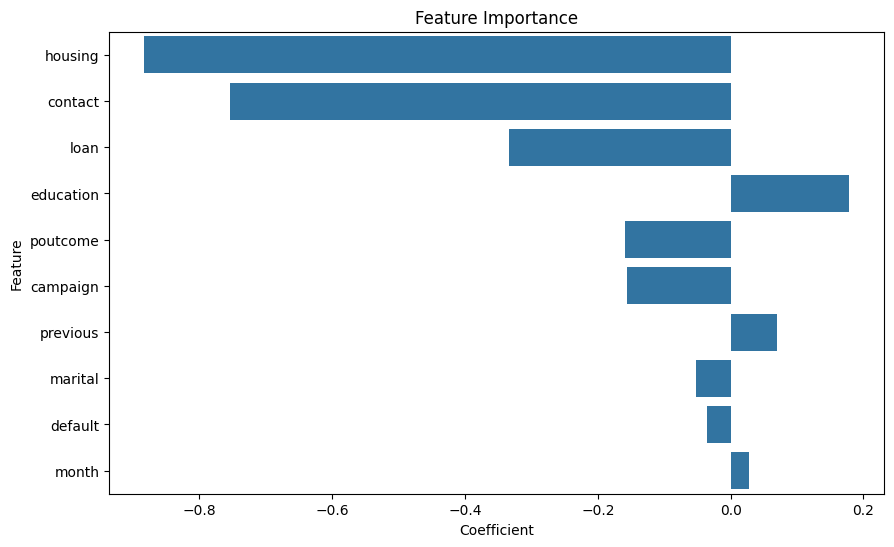


Business Insights:
- Identify customer groups with higher acceptance rate
- Focus marketing on high-probability segments
- Job, age, and marital status are usually strong indicators

Acceptance Rate by Job:
deposit               no        yes
job                                
admin.         52.698651  47.301349
blue-collar    63.580247  36.419753
entrepreneur   62.500000  37.500000
housemaid      60.218978  39.781022
management     49.298519  50.701481
retired        33.676093  66.323907
self-employed  53.827160  46.172840
services       60.021668  39.978332
student        25.277778  74.722222
technician     53.922106  46.077894
unemployed     43.417367  56.582633
unknown        51.428571  48.571429

Acceptance Rate by Marital Status:
deposit          no        yes
marital                       
divorced  51.894818  48.105182
married   56.621005  43.378995
single    45.650938  54.349062

Model Completed Successfully!


In [8]:
# ==========================================
# Personal Loan Acceptance Prediction
# Bank Marketing Dataset (ROBUST VERSION)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------
# Load Dataset
# ------------------------------------------
df = pd.read_csv("/content/bank.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
print(df.head())

# ------------------------------------------
# FIND TARGET COLUMN AUTOMATICALLY
# ------------------------------------------
possible_targets = ['y', 'deposit', 'loan', 'subscribed', 'target', 'response']

target = None
for col in possible_targets:
    if col in df.columns:
        target = col
        break

if target is None:
    # fallback: assume last column is target
    target = df.columns[-1]

print("\nDetected Target Column:", target)

# ------------------------------------------
# DATA CLEANING / ENCODING
# ------------------------------------------
df_clean = df.copy()

# Encode all categorical columns
label_encoders = {}

for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col])
        label_encoders[col] = le

# ------------------------------------------
# DATA EXPLORATION (VISUALS)
# ------------------------------------------

# Age distribution (if exists)
if 'age' in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df['age'], bins=20, kde=True)
    plt.title("Age Distribution")
    plt.show()

# Job vs Target
if 'job' in df.columns:
    plt.figure(figsize=(12,5))
    sns.countplot(data=df, x='job', hue=target)
    plt.xticks(rotation=45)
    plt.title("Job vs Loan Acceptance")
    plt.show()

# Marital vs Target
if 'marital' in df.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x='marital', hue=target)
    plt.title("Marital Status vs Loan Acceptance")
    plt.show()

# ------------------------------------------
# FEATURES & TARGET
# ------------------------------------------
X = df_clean.drop(target, axis=1)
y = df_clean[target]

# ------------------------------------------
# TRAIN TEST SPLIT
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------
# LOGISTIC REGRESSION MODEL
# ------------------------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# ------------------------------------------
# EVALUATION
# ------------------------------------------
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------------------------------
# FEATURE IMPORTANCE (LOGISTIC COEFFICIENTS)
# ------------------------------------------
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance["Abs"] = abs(importance["Coefficient"])
importance = importance.sort_values("Abs", ascending=False)

print("\nTop Features:")
print(importance.head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(10), x="Coefficient", y="Feature")
plt.title("Feature Importance")
plt.show()

# ------------------------------------------
# BUSINESS INSIGHTS
# ------------------------------------------
print("\nBusiness Insights:")
print("- Identify customer groups with higher acceptance rate")
print("- Focus marketing on high-probability segments")
print("- Job, age, and marital status are usually strong indicators")

# Acceptance rate by job (if exists)
if 'job' in df_clean.columns:
    print("\nAcceptance Rate by Job:")
    print(pd.crosstab(df['job'], df[target], normalize='index') * 100)

# Acceptance rate by marital status
if 'marital' in df_clean.columns:
    print("\nAcceptance Rate by Marital Status:")
    print(pd.crosstab(df['marital'], df[target], normalize='index') * 100)

print("\nModel Completed Successfully!")